# Maternal Health Risk Predictor
Predicts whether a pregnant woman is at **low**, **mid**, or **high** risk based on 6 basic vitals.

Dataset: [Maternal Health Risk Data — Kaggle](https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data)

## Section 1 — Imports & Load Data

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv('maternal_health_risk.csv')
print('Shape:', df.shape)
df.head()

Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## Section 2 — EDA

In [10]:
# Basic info
print(df.info())
print('\nNull values:\n', df.isnull().sum())
print('\nClass distribution:\n', df['RiskLevel'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB
None

Null values:
 Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Class distribution:
 RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


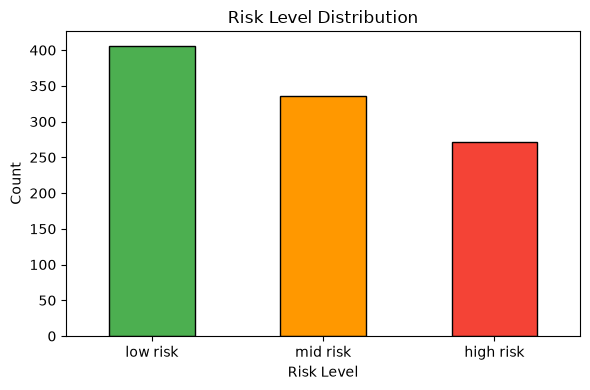

In [11]:
# Class distribution bar chart
plt.figure(figsize=(6, 4))
df['RiskLevel'].value_counts().plot(kind='bar', color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='black')
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Statistical summary
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


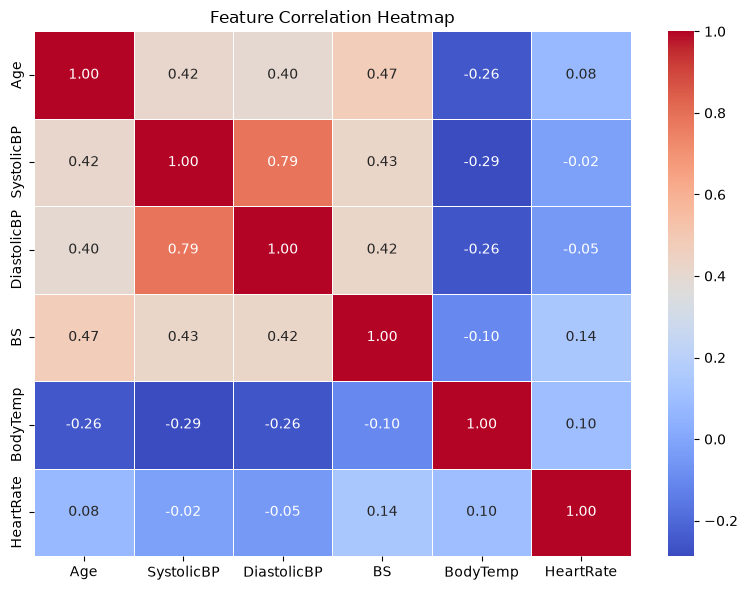

In [13]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.drop(columns='RiskLevel').corr(),
    annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

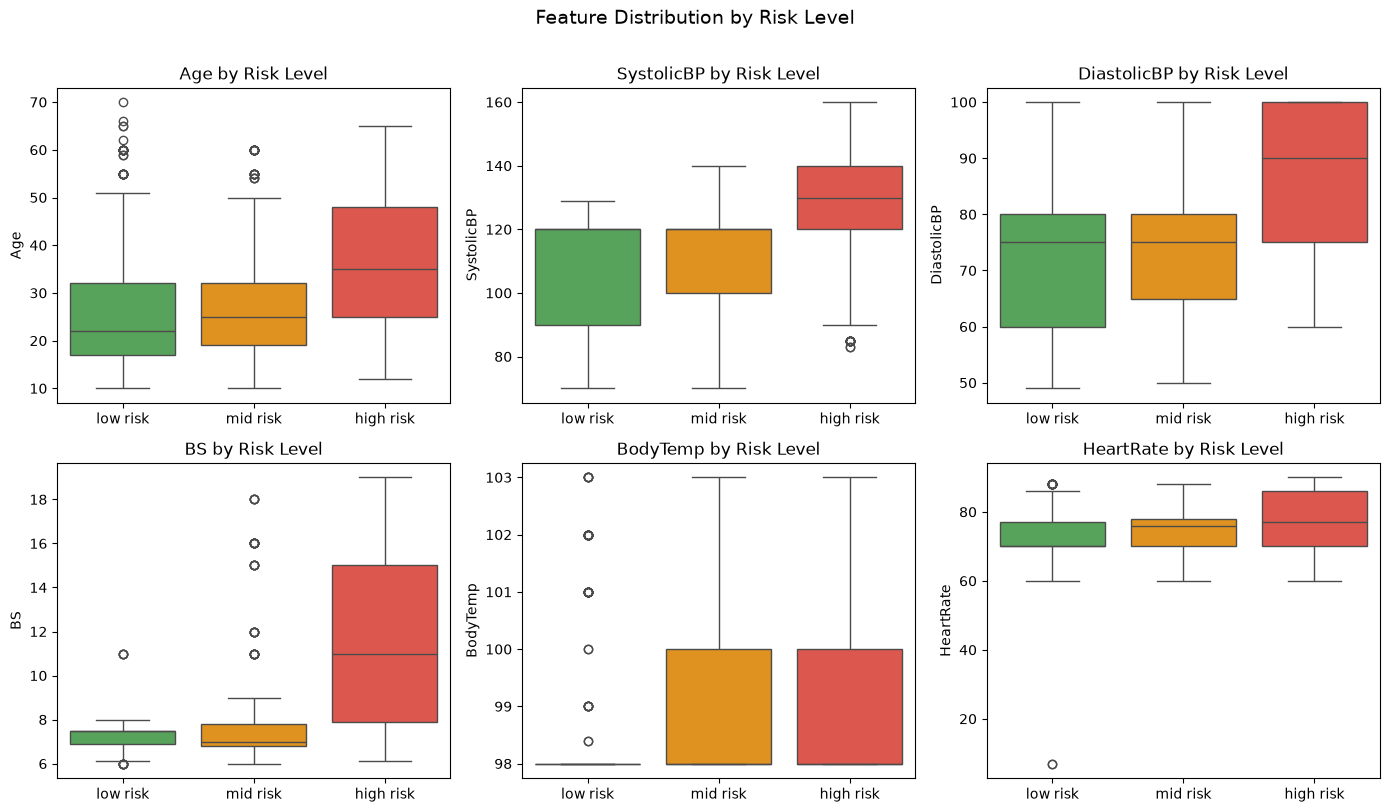

In [14]:
# Box plots — each feature split by risk level
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df, x='RiskLevel', y=feature,
        order=['low risk', 'mid risk', 'high risk'],
        palette=['#4CAF50', '#FF9800', '#F44336'],
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} by Risk Level')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distribution by Risk Level', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Section 3 — Preprocessing + SMOTE

In [15]:
# Encode target label
le = LabelEncoder()
df['RiskLevel_encoded'] = le.fit_transform(df['RiskLevel'])
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df[features]
y = df['RiskLevel_encoded']

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Class mapping: {'high risk': np.int64(0), 'low risk': np.int64(1), 'mid risk': np.int64(2)}
Train size: 811 | Test size: 203


In [16]:
# Apply SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', dict(zip(*np.unique(y_train, return_counts=True))))
print('After SMOTE: ', dict(zip(*np.unique(y_train_sm, return_counts=True))))

Before SMOTE: {np.int64(0): np.int64(217), np.int64(1): np.int64(325), np.int64(2): np.int64(269)}
After SMOTE:  {np.int64(0): np.int64(325), np.int64(1): np.int64(325), np.int64(2): np.int64(325)}


In [17]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

## Section 4 — Train Random Forest & Logistic Regression

In [18]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train_sm)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)

print('Both models trained.')

Both models trained.


## Section 5 — Evaluate & Compare

In [19]:
# Predictions
rf_preds = rf.predict(X_test_scaled)
lr_preds = lr.predict(X_test_scaled)

# Accuracy
rf_acc = accuracy_score(y_test, rf_preds)
lr_acc = accuracy_score(y_test, lr_preds)

print(f'Random Forest Accuracy : {rf_acc:.4f}')
print(f'Logistic Regression Accuracy: {lr_acc:.4f}')

Random Forest Accuracy : 0.8818
Logistic Regression Accuracy: 0.6059


In [20]:
# Classification reports
class_names = le.classes_

print('=== Random Forest ===')
print(classification_report(y_test, rf_preds, target_names=class_names))

print('=== Logistic Regression ===')
print(classification_report(y_test, lr_preds, target_names=class_names))

=== Random Forest ===
              precision    recall  f1-score   support

   high risk       0.93      0.95      0.94        55
    low risk       0.93      0.83      0.88        81
    mid risk       0.80      0.90      0.85        67

    accuracy                           0.88       203
   macro avg       0.89      0.89      0.89       203
weighted avg       0.89      0.88      0.88       203

=== Logistic Regression ===
              precision    recall  f1-score   support

   high risk       0.75      0.80      0.77        55
    low risk       0.61      0.70      0.65        81
    mid risk       0.44      0.33      0.38        67

    accuracy                           0.61       203
   macro avg       0.60      0.61      0.60       203
weighted avg       0.59      0.61      0.59       203



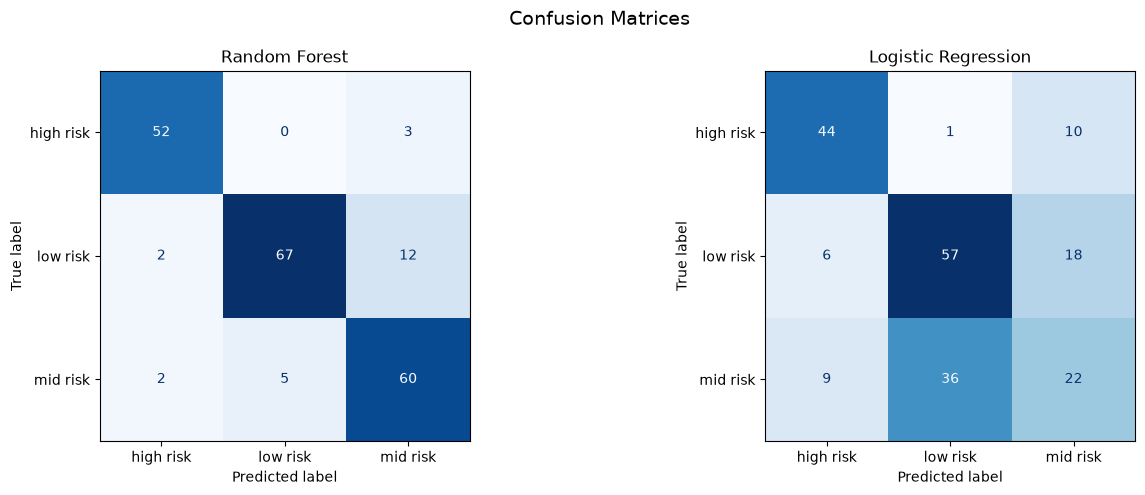

In [21]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [rf_preds, lr_preds],
    ['Random Forest', 'Logistic Regression']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

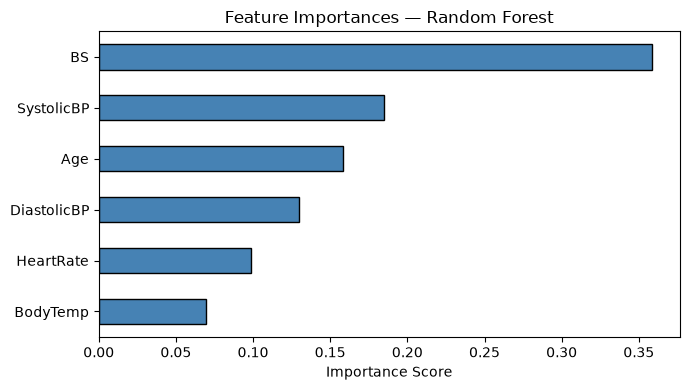

In [22]:
# Feature importance (Random Forest only)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

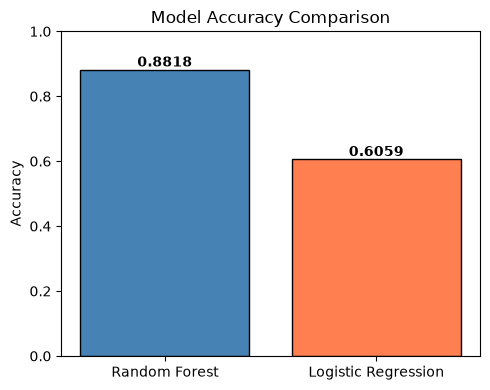

In [23]:
# Accuracy comparison bar chart
plt.figure(figsize=(5, 4))
plt.bar(['Random Forest', 'Logistic Regression'], [rf_acc, lr_acc],
        color=['steelblue', 'coral'], edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for i, v in enumerate([rf_acc, lr_acc]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6 — Save Model & Scaler

In [24]:
# Save the best model (Random Forest) and the scaler
with open('maternal_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Saved: maternal_model.pkl, scaler.pkl, label_encoder.pkl')

Saved: maternal_model.pkl, scaler.pkl, label_encoder.pkl


In [25]:
# Quick sanity check — run a sample prediction
sample = pd.DataFrame([{
    'Age': 25,
    'SystolicBP': 130,
    'DiastolicBP': 90,
    'BS': 15.0,
    'BodyTemp': 98.0,
    'HeartRate': 86
}])

sample_scaled = scaler.transform(sample)
prediction = rf.predict(sample_scaled)
print('Predicted Risk Level:', le.inverse_transform(prediction)[0])

Predicted Risk Level: high risk
